In [1]:
%matplotlib inline
# changed from %matplotlib notebook as graphs werent being plotted 

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq 
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [3]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [4]:
from miRBench.dataset import list_datasets, get_dataset_df

In [5]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/dave/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [6]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

# Optimization

### Simple model on miRNA alignments:

In [7]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [8]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [9]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

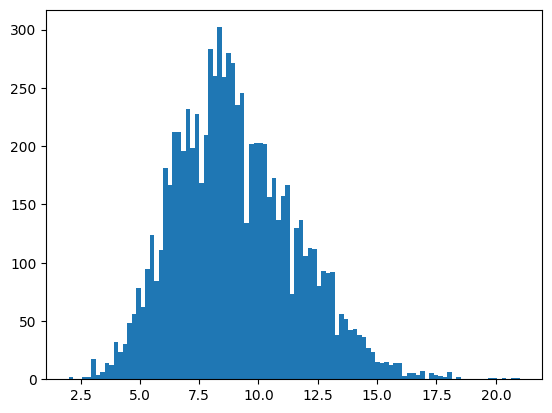

In [10]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [11]:
true_alpha = -9
## true_alpha = -np.median(scores)

In [12]:
logit_scores = logit_partial_scores(scores, true_alpha)

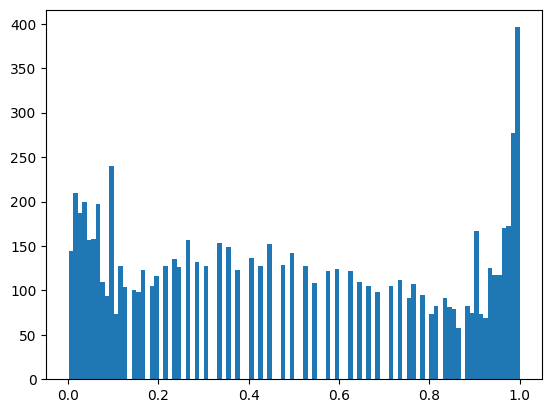

In [13]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

### Test Run

In [14]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
labels

array([False,  True, False, ..., False, False,  True], shape=(8193,))

In [15]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL) ## This is different 

Sum of log-logit scores: -10002.78024009512
True LogL: -3298.2802400951223


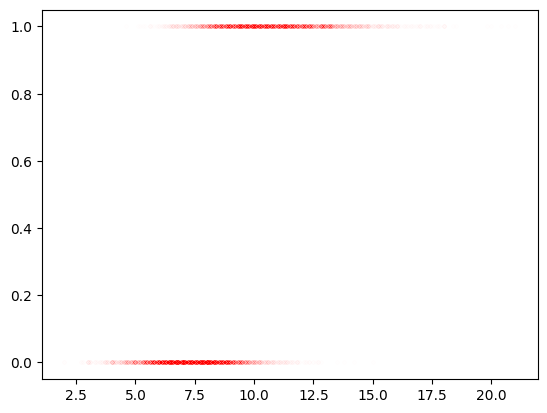

In [16]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

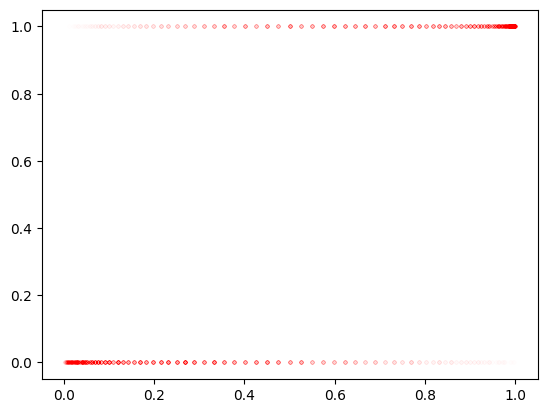

In [17]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [18]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [19]:
NITER = 50 # original 50

In [20]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    verbose=True, max_iter=NITER,
                    stochastic_factor=None,
                    num_threads = 16)

Alphabet:
TACG


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Initial parameters:
{'alpha': np.float64(-8.003302344121712), 'match_score': np.float64(0.939211480149184), 'mismatch_score': np.float64(-0.8635627449034454), 'open_gap_score': np.float64(-1.2492914520096585), 'extend_gap_score': np.float64(-0.09038659127006578)}
Start of iteration 0
Current alpha: -8.003302344121712
Current logL: -3337.7736587803447
Updated alpha: -8.153619976720034
Updated logL: -3325.2298091795706
New subgradient:
{'Substitutions': Array([[ 98.51918392, -22.58026647, -34.30386314, -10.91507075],
       [-17.89170955,   6.32311532,   2.05175845,  -3.74612365],
       [ -7.62481861, -10.90708657, 138.02520144, -26.72307548],
       [-14.41132842, -12.72783087, -26.02510539,  50.53700717]],
         alphabet='TACG'), 'Gap opens': np.float64(237.3529681899035), 'Gap extends': np.float64(439.1796338002731)}
Stepsize: 1e-05
Gap open step: 0.002373529681899035
Gap extend step: 0.004391796338002732
Match step: 0.0029340450784562234
Mismatch step: -0.0018580452043781299
New 

In [21]:
print(params['final_loglik'])

-3301.810772170581


In [22]:
print(params['final_loglik'])

-3301.810772170581


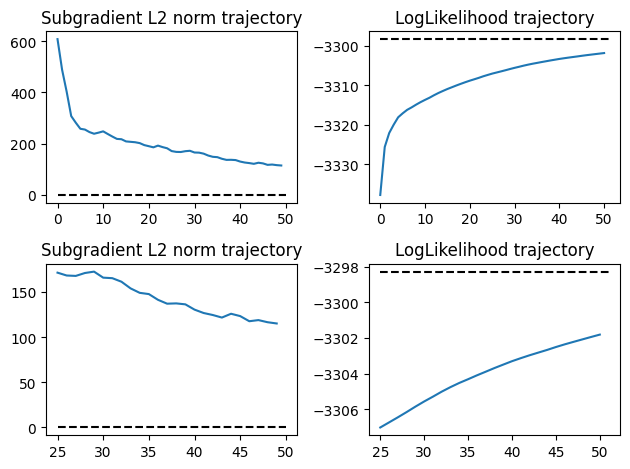

In [23]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

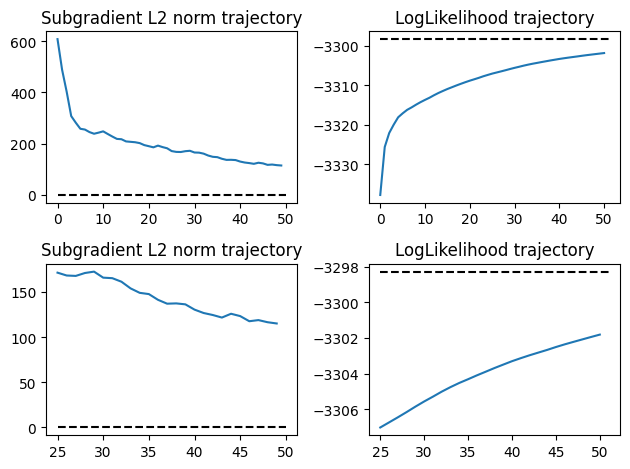

In [24]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [25]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 0.9804539803744705
-1 -0.9286309552225633
-1.2 -1.1966088306171683
-0.1 -0.09202584304569328
-9 -8.838261296797006


### Additional plotting

In [26]:
# ## Freezing dataset values so true loglikliehood is not recomputed after every iteration 

# rng = np.random.default_rng(0)

# # fixed labels 
# labels_frozen = rng.random(len(mirlist)) <= logit_partial_scores(scores, true_alpha)

# # fixed model probabilities for true log-likelihood
# logit_scores_frozen = logit_partial_scores(scores, true_alpha)

# # compute true log-likelihood ONCE
# true_logL_frozen = (
#     np.sum(np.log(logit_scores_frozen[labels_frozen])) +
#     np.sum(np.log(1 - logit_scores_frozen[~labels_frozen]))
# )

In [27]:
# # Run estimalign across different step sizes and plot:
# # (1) logL trajectories to see convergence behavior
# # (2) scatter of convergence speed vs final parameter error to find the best step size

# step_sizes = [0.000005, 0.00001, 0.00005, 0.0001, 0.0005]
# task1_results = {}

# for ss in step_sizes:
#     step = create_constant_step(ss)
#     p = estimalign(mirlist, genelist, labels_frozen, ## labels_frozen now used 
#                    stepfunction=step, aligner_mode='local',
#                    substitution_mode='simple', verbose=False,
#                    max_iter=NITER, stochastic_factor=None, num_threads=16)
#     task1_results[ss] = p

# # Trajectory plot
# plt.figure()
# for ss, p in task1_results.items():
#     plt.plot(p['loglik_trajectory'], label=f'step={ss}')
# plt.axhline(true_logL, color='k', linestyle='--', label='True LogL')
# plt.xlabel('Iteration'); plt.ylabel('LogL')
# plt.title('LogL Trajectories by Step Size')
# plt.legend(); plt.tight_layout(); plt.show()

# # Scatter: convergence speed vs final parameter error
# def param_error(p):
#     return (abs(p['match_score'] - true_match) +
#             abs(p['mismatch_score'] - true_mismatch) +
#             abs(p['open_gap_score'] - true_gapopen) +
#             abs(p['extend_gap_score'] - true_gapext) +
#             abs(p['alpha'] - true_alpha))

# # convergence = first iteration where subgradient L2 norm drops below threshold
# threshold = 0.01
# conv_iters = []
# errors = []
# for ss, p in task1_results.items():
#     grads = p['subgradient_l2_trajectory']
#     conv = next((i for i, g in enumerate(grads) if g < threshold), NITER)
#     conv_iters.append(conv)
#     errors.append(param_error(p))

# plt.figure()
# for i, ss in enumerate(step_sizes):
#     plt.scatter(conv_iters[i], errors[i], label=f'step={ss}', s=100)
# plt.xlabel('Iterations to Converge')
# plt.ylabel('Total Parameter Error')
# plt.title('Convergence Speed vs Parameter Error')
# plt.legend(); plt.tight_layout(); plt.show()

In [28]:
# # Run estimalign 20 times with different random seeds and plot:
# # 1) a histogram of mean parameter error per run
# # 2) per-parameter boxplots to show which parameters are reliably recovered

# N_SEEDS = 20
# best_step = 0.000005 # best step size from task 1 

# # If we treat alpha as a single constant parameter then there wont be any error, so I removed it
# # For some reason doing that changes all of the error to the same bins  

# param_names = ['match_score', 'mismatch_score', 'open_gap_score', 'extend_gap_score']
# true_values = [true_match, true_mismatch, true_gapopen, true_gapext]

# per_param_errors = {name: [] for name in param_names}
# mean_errors = []

# for seed in range(N_SEEDS):
#     rd.seed(seed)

#     p = estimalign(mirlist, genelist, labels_frozen, ## changed labels to labels_frozen
#                    stepfunction=create_constant_step(best_step), aligner_mode='local',
#                    substitution_mode='simple', verbose=False,
#                    max_iter=NITER, stochastic_factor=None, num_threads=16)

#     errors = []
#     for name, true_val in zip(param_names, true_values):
#         err = abs(p[name] - true_val)
#         per_param_errors[name].append(err)
#         errors.append(err)

#     mean_errors.append(np.mean(errors))

# # Histogram: mean error per run
# plt.figure()
# plt.hist(mean_errors, bins=10, edgecolor='black')
# plt.xlabel('Mean Absolute Parameter Error')
# plt.ylabel('Count')
# plt.title('Distribution of Mean Parameter Error Across 20 Runs')
# plt.tight_layout()
# plt.show()

# # Boxplots: per-parameter error 
# plt.figure()
# plt.boxplot(per_param_errors.values(), labels=param_names, showfliers=True)
# plt.ylabel('Mean Absolute Error')
# plt.title('Per-Parameter Recovery Error Across 20 Runs')
# plt.xticks(rotation=15)
# plt.tight_layout()
# plt.show()

### Step function parameters experiment

In [29]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [30]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [31]:
steplengths = np.linspace(0.000005, 0.00005, num=10)
steplengths

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [32]:
NITER = 200

In [33]:
# Get the best step size from the first experiment (lowest pen wins)
def step_penalty(logL, true_logL):
    return abs(logL - true_logL)

In [34]:
# Get the iteration at which convergence happens (speed)
# by also measuring speed, a tradeoff between speed and quality (measured above) happes
def get_convergence_iter(params, true_logL, tol=1.0):
    for i, logL in enumerate(params['loglik_trajectory']):
        if step_penalty(logL, true_logL) < tol:
            return i
    return len(params['loglik_trajectory']) - 1

In [ ]:
estimalign_results_step = []

conv_iters = []
penalties = []

for stepl in steplengths:
    const_step = create_constant_step(stepl)
    
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results_step.append(params)

    final_logL = params['loglik_trajectory'][-1]

    penalty = step_penalty(final_logL, true_logL)
    penalties.append(penalty)

    conv_iter = get_convergence_iter(params, true_logL, tol = 0.1) # tolerance may be low but we will see 
    conv_iters.append(conv_iter)

    if conv_iter < NITER:
        print(f"step={stepl:.2e}, penalty={penalty:.4f}, converged at iteration {conv_iter}")
    else:
        print(f"step={stepl:.2e}, penalty={penalty:.4f}, did NOT converge") 

best_step = steplengths[np.argmin(penalties)]
print(f"\nBest step to be used for replicate experiment: ", best_step)

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


step=5.00e-06, penalty=0.1616, did NOT converge


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


step=1.00e-05, penalty=1.5392, converged at iteration 101


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

step=4.00e-05, penalty=2.1306, converged at iteration 25


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


step=4.50e-05, penalty=2.1301, converged at iteration 23


/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


step=5.00e-05, penalty=1.1922, converged at iteration 24

Best step to be used for replicate experiment:  5e-06


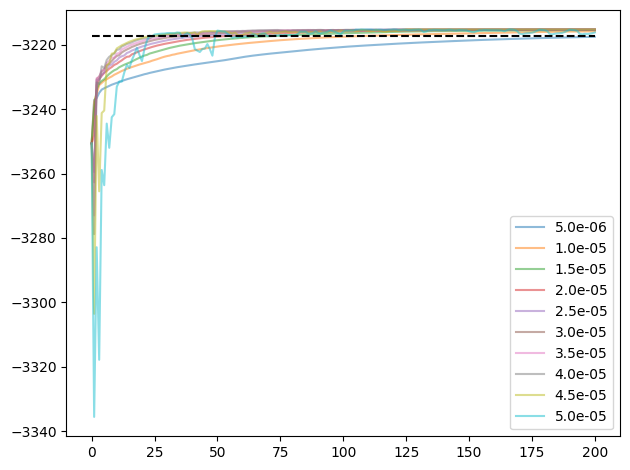

In [ ]:
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.tight_layout()
# plt.savefig('path', dpi=160)

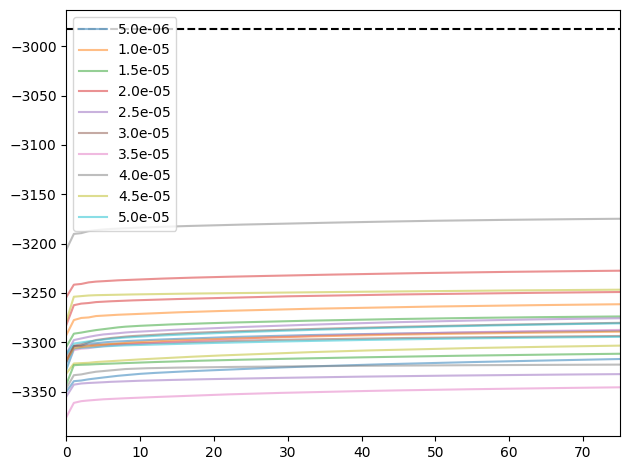

In [ ]:
# below needs to be done again 
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.xlim(25, 75) 
plt.tight_layout()

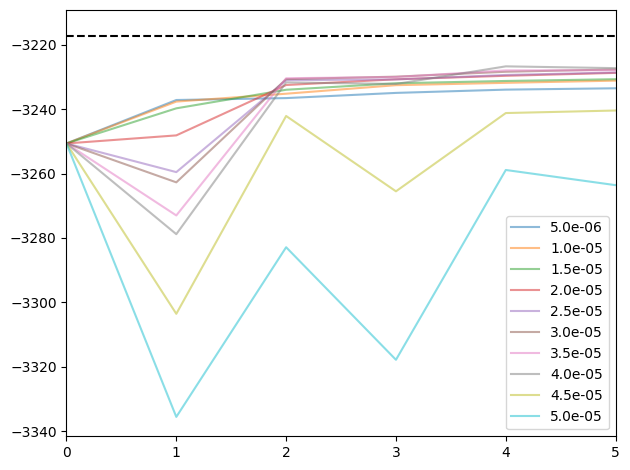

In [ ]:
plt.figure()
for params in estimalign_results_step:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend([f"{sl:.1e}" for sl in steplengths])
plt.xlim(0, 5)
plt.tight_layout()

### Replicates

In [38]:
REPS = 20
NITER = 200

In [ ]:
const_step = create_constant_step(3.0e-05) # updated to choose best step from prev exp ####3.0e-05
# const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [ ]:
estimalign_results_rep = []
true_logLs = []
conv_iters_rep = [] # Checks if the chosen step size is stable in convergence across different datasets

for _ in range(REPS):
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    true_logLs.append(true_logL)
    params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    estimalign_results_rep.append(params)

    conv_iter = get_convergence_iter(params, true_logL, tol=1.0)
    conv_iters_rep.append(conv_iter)

for i, it in enumerate(conv_iters_rep):
    if it < NITER - 1:
        print(f"rep {i} converged at iteration {it}")
    else:
        print(f"rep {i} did NOT converge")

/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/dave/Documents/Bioinformatics/estimalign/env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

rep 0 converged at iteration 173
rep 1 converged at iteration 181
rep 2 converged at iteration 142
rep 3 converged at iteration 177
rep 4 converged at iteration 48
rep 5 did NOT converge
rep 6 converged at iteration 130
rep 7 converged at iteration 128
rep 8 did NOT converge
rep 9 did NOT converge
rep 10 did NOT converge
rep 11 did NOT converge
rep 12 converged at iteration 114
rep 13 converged at iteration 109
rep 14 converged at iteration 165
rep 15 converged at iteration 198
rep 16 did NOT converge
rep 17 converged at iteration 14
rep 18 converged at iteration 167
rep 19 did NOT converge


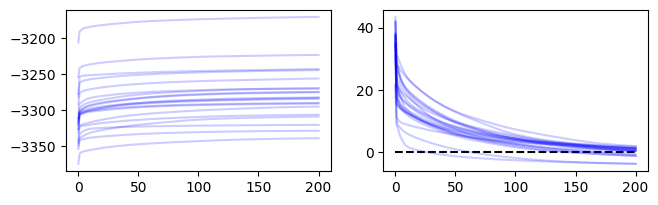

In [ ]:
plt.figure(figsize=(7.5, 2.1))
plt.subplot(121)
for params in estimalign_results_rep:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.2, color='b')
plt.subplot(122)
plt.plot([0, NITER], [0, 0], 'k--')
for params, tlL in zip(estimalign_results_rep, true_logLs):
    plt.plot(np.arange(NITER+1), tlL - params['loglik_trajectory'], alpha=0.2, color='b')

### General matrix, affine gap penalty

In [42]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

In [43]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [44]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

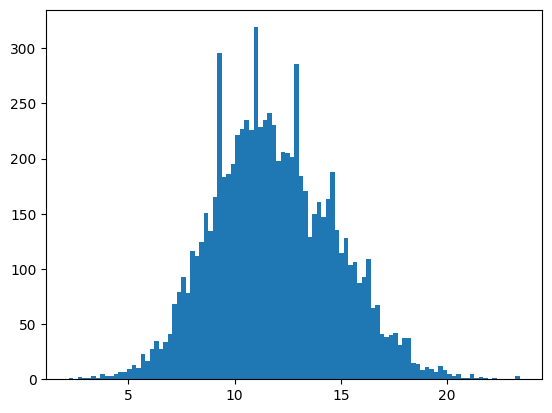

In [45]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [46]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

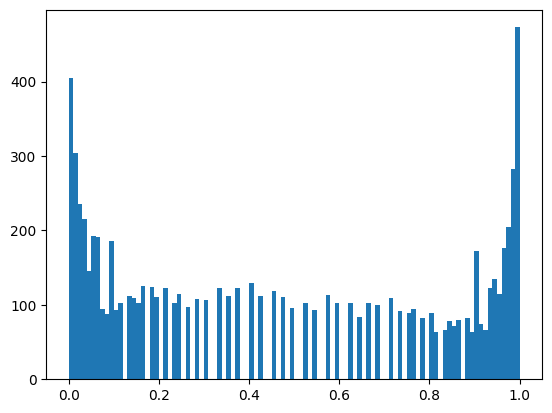

In [47]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [48]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11654.43085041492
True LogL: -2983.030850414926


In [49]:
const_step = create_constant_step(0.00005)
# powerstep = create_powerstep(0.00005, power=0.5, burnin=0)
powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [50]:
NITER = 200

In [51]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    stochastic_factor=0.01,
                    verbose=True, max_iter=NITER,
                    num_threads = 24)

Alphabet:
TACG
Initial parameters:
{'alpha': np.float64(-9.343242330115261), 'substitution_matrix': Array([[ 0.82846261, -0.85293539, -0.52915877, -0.73454162],
       [-0.80279951,  0.83726255, -0.39838968, -0.62583042],
       [-0.38090996, -0.63828335,  1.0383721 , -0.82853943],
       [-0.70709523, -0.44697576, -0.8448301 ,  1.12190884]],
         alphabet='TACG'), 'open_gap_score': np.float64(-1.182258998728003), 'extend_gap_score': np.float64(-0.08227429811565994)}
Start of iteration 0
Current alpha: -9.343242330115261
Current logL: -3068.7992631228226
Updated alpha: -9.622307520121868
Updated logL: -3028.1623129644554
New subgradient:
{'Substitutions': Array([[151.28111037, -21.50441375,  35.13224147, -13.09860539],
       [-15.41823706, 114.77214216,  27.76671598, -11.27424837],
       [ 12.32166799,   9.46542221, 145.84821252,   0.82678191],
       [ -5.79156008,  34.65574628, -20.03543372,  77.22704181]],
         alphabet='TACG'), 'Gap opens': np.float64(199.62978472980012),

In [52]:
print(params['final_loglik'])

-2981.6491643700683


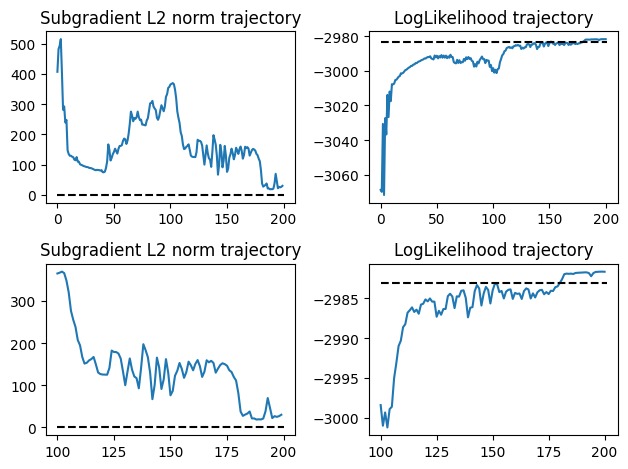

In [53]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [54]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))
print(np.mean(np.abs(np.array(true_subs_vector)- np.array(param_subs_vector))))

-1.2 -1.1697940216639415
-0.1 -0.09787228441532277
-12 -11.991102236638042
A A 1.0 0.985498062365243
A C -0.3 -0.2759020429424893
A T -1.0 -0.9433157390148874
A G -0.8 -0.6669191229915208
C A -0.6 -0.6166481762630095
C C 1.2 1.1900759629841204
C T -0.3 -0.32395425530248534
C G -1.0 -0.8113184842676346
T A -1.2 -0.9721530653636952
T C -0.4 -0.38021224906611495
T T 1.0 0.9720635929772367
T G -0.8 -0.7868031105245354
G A -0.4 -0.3322725125602807
G C -1.4 -1.0099718165938216
G T -0.9 -0.7724480993369555
G G 1.3 1.2783460202866845
[[1.         0.99464664]
 [0.99464664 1.        ]]
0.08520640939314218


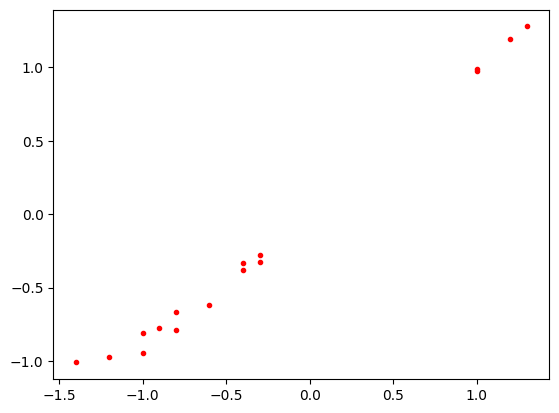

In [55]:
plt.figure()
plt.plot(true_subs_vector, param_subs_vector, 'r.')

In [56]:
from src.optimization import get_initial_estimate

In [57]:
get_initial_estimate(params['alignments'], labels, substitution_mode='general', gap_mode='affine',
                     alphabet=true_substitution.alphabet)

{'alpha': np.float64(-12.092411247673455),
 'substitution_matrix': Array([[ 0.99797664, -0.27616593, -1.06729855, -0.69788832],
        [-0.63106746,  1.20261854, -0.32377013, -0.80942432],
        [-1.02638162, -0.37646131,  0.98599856, -0.82337353],
        [-0.33212361, -1.16105137, -0.8094786 ,  1.29294072]],
          alphabet='ACTG'),
 'open_gap_score': np.float64(-1.1868392601112991),
 'extend_gap_score': np.float64(-0.10028548999458482)}

In [58]:
true_substitution

Array([[ 1. , -0.3, -1. , -0.8],
       [-0.6,  1.2, -0.3, -1. ],
       [-1.2, -0.4,  1. , -0.8],
       [-0.4, -1.4, -0.9,  1.3]],
         alphabet='ACTG')

In [59]:
estim_substitution = true_substitution.copy()
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        estim_substitution[char1, char2] = params['substitution_matrix'][char1, char2]

In [60]:
estim_substitution

Array([[ 0.98549806, -0.27590204, -0.94331574, -0.66691912],
       [-0.61664818,  1.19007596, -0.32395426, -0.81131848],
       [-0.97215307, -0.38021225,  0.97206359, -0.78680311],
       [-0.33227251, -1.00997182, -0.7724481 ,  1.27834602]],
         alphabet='ACTG')